# Post processed clouds on top of an atmospheric model

The most straight forward use of Nimbus is as post processing tool for clouds based on a given atmospheric profle. Here we show the example of how Nimbus clouds can be calculated based on Sonora Diamondback models for a cloud structure made from SiO2 and MgSiO3. To start we need to define the necessary atmospheric parameters

In [1]:
planet_gravity = 3100  # in cm/s^2
planet_mmw = 2.34  # mean molecular weight of the planet in amu
cloud_species = ['SiO2', 'MgSiO3']  # name of the cloud species
cloud_species_mmr = [3e-3, 5e-4]  # in [g/g] and same order as cloud_species
cloud_species_cant_nucleate = ['MgSiO3']  # species which cannot nucleate

To start the calculation we need the atmpspheric structuer which we read in from the Sonora Diamondback models and we assume a Kzz of 1e10.

In [2]:
import numpy as np

# ==== read in the tp profile
tpname = 't1500g316f2_m0.0_co1.0.pt'
tp_profile = np.genfromtxt(tpname, skip_header=2)

# ==== prepare data for Nimbus
pressures = tp_profile[:, 1]  # in bars
temperatures = tp_profile[:, 2]  # in K
kzz = 1e10 * np.ones_like(temperatures)  # in cm2/s

To set up Nimbus we first create the class object, where we define the working directory, and then give it the atmospheric structer. Nimbus then calculates all dependent parameters internally. **Important** all units are cgs, except pressure which is in bar. Also important, even though all in and outputs are allways in bar, if you manipulate Nimbus internally remember that all pressures are handled in dyn/cm^2 internally.

In [3]:
from nimbus import Nimbus

# ==== Set up Nimbus object
nimb = Nimbus(working_dir='working/', verbose=True)

# ==== Set up Nimbus atmosphere structure
nimb.set_up_atmosphere(
    temperatures, pressures, kzz, planet_mmw,
    planet_gravity, cloud_species, cloud_species_mmr,
    ignore_as_nucleator=cloud_species_cant_nucleate
)

                   Welcome to Nimbus                       
[INFO] For questions contact: kiefersv.mail@gmail.com
[INFO] Settings selected:
       -> working directory: working/
       -> verbose: True
       -> analytic plots: False
[INFO] Atmosphere set up with:
       -> pressure range: 6.37e+01 - 1.78e-04 bar
       -> temperature range: 3.77e+03 - 7.52e+02 K
       -> Kzz range at t=0: 1.00e+10 - 1.00e+10 cm2/s
       -> Mean molecular weight: 2.34e+00 amu
       -> Gravity: 3.10e+03 cm/s2
       -> SiO2 deep MMR: 3.00e-03 g/g
       -> MgSiO3 deep MMR: 5.00e-04 g/g


To run the code you know only need to execute Nimbus

In [4]:
ds = nimb.compute(typ='full')

[INFO] Computation function call
[WARN] Solver set up automatically. Use set_up_solver() for more control.
[INFO] Solver set up.
[INFO] Computation started
[INFO] Cloud structures completed in 76.05s (1 iterations).
[INFO] Saved run under tag: last_run


Now that we have the cloud structure we can plot the results. A basic analysis plot might look something like this:

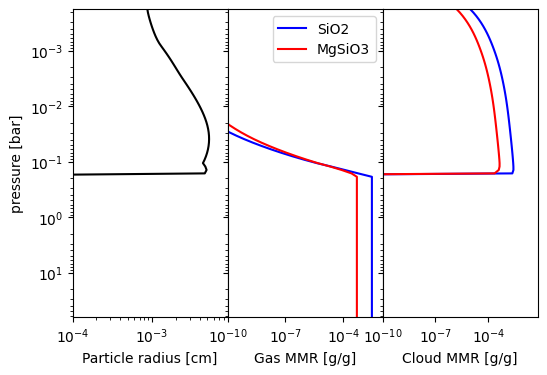

In [5]:
import matplotlib.pyplot as plt

# ==== plot results
fig, ax = plt.subplots(1, 3, figsize=(6,4))
ax[0].plot(ds['cloud_radius'][:-2], ds['pressure'][:-2], color='k')
ax[2].plot(ds['cloud_mmr'][0], ds['pressure'], color='blue')
ax[2].plot(ds['cloud_mmr'][1], ds['pressure'], color='red')
ax[1].plot(ds['gas_mmr'][0], ds['pressure'], color='blue', label='SiO2')
ax[1].plot(ds['gas_mmr'][1], ds['pressure'], color='red', label='MgSiO3')

# ==== make the plot pretty
for axi in ax:
    axi.set_ylim(bottom=ds['pressure'][-1], top=ds['pressure'][0])
    axi.set_yscale('log')
    axi.set_xscale('log')
plt.subplots_adjust(wspace=0)
ax[0].set_ylabel('pressure [bar]')
ax[2].set_xlabel('Cloud MMR [g/g]')
ax[1].set_xlabel('Gas MMR [g/g]')
ax[0].set_xlabel('Particle radius [cm]')
ax[1].get_yaxis().set_ticklabels([])
ax[2].get_yaxis().set_ticklabels([])
ax[0].set_xlim(1e-4)
ax[1].set_xlim(1e-10)
ax[2].set_xlim(1e-10)
ax[1].legend()
plt.show()